<a href="https://colab.research.google.com/github/jaacobbb/nil-valuation-engine/blob/main/wrModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# This mounts your Google Drive to the Colab VM.
#pff login: email: jacoblee@stanford.edu, pwd: Zwialg41!
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs141assignments/assignment2/'
FOLDERNAME = 'Colab Notebooks/nil_evaluation_model'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# TODO: cd into the correct assignment directory
%cd "/content/drive/My Drive/Colab Notebooks/nil_evaluation_model"

Mounted at /content/drive
/content/drive/My Drive/Colab Notebooks/nil_evaluation_model


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from bs4 import BeautifulSoup
import requests

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import sklearn.metrics
import time
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
#getting data from pff receiving summaries
STATS_TO_KEEP = [
    'player',
    'player_id',
    'position',
    'player_game_count',
    'targets',
    'routes',
    # Rate-based features only
    'yprr',                        # yards per route run — best single WR metric
    'caught_percent',              # catch rate
    'yards_per_reception',         # efficiency per catch
    'yards_after_catch_per_reception', # YAC ability
    'avg_depth_of_target',         # scheme context / route depth
    'route_rate',                  # involvement / trust from QB
    'drop_rate',                   # ball security
    'contested_catch_rate',        # winning 50/50 balls
    'targeted_qb_rating',          # QB rating when targeting this WR
    'grades_pass_route',           # PFF route running grade
    'grades_offense',              # overall offensive grade
]

pff_all = []

for year in range(2010, 2025):
    path = f'NFLData/wrdata/receiving_data/receiving_summary_{year}.csv'
    df   = pd.read_csv(path)

    cols_available = [c for c in STATS_TO_KEEP if c in df.columns]
    df = df[cols_available].copy()
    df['year'] = year
    pff_all.append(df)
    print(f'{year}: {len(df)} WRs loaded')

pff_df = pd.concat(pff_all, ignore_index=True)
print(f'\nTotal before filter: {len(pff_df)} rows')

# Filter: minimum route and target thresholds to ensure sample size reliability
# 35 routes/game ≈ a starter's route participation (~550+ routes over 16 games)
# Using per-game rates to handle injury-shortened seasons (same logic as QB)
pff_df['routes_per_game'] = pff_df['routes'] / pff_df['player_game_count']
pff_df['targets_per_game'] = pff_df['targets'] / pff_df['player_game_count']

before = len(pff_df)
pff_df = pff_df[
    (pff_df['routes_per_game'] >= 25) &   # starter-level route participation
    (pff_df['targets_per_game'] >= 3)      # meaningful target share
].copy()

print(f'Removed {before - len(pff_df)} WRs below threshold ({len(pff_df)} remaining)')
print(f'Unique WRs: {pff_df["player"].nunique()}')

# Drop helper columns
pff_df = pff_df.drop(columns=['routes', 'targets', 'routes_per_game', 'targets_per_game', 'position'])

2010: 459 WRs loaded
2011: 481 WRs loaded
2012: 492 WRs loaded
2013: 481 WRs loaded
2014: 481 WRs loaded
2015: 485 WRs loaded
2016: 490 WRs loaded
2017: 481 WRs loaded
2018: 514 WRs loaded
2019: 509 WRs loaded
2020: 526 WRs loaded
2021: 538 WRs loaded
2022: 510 WRs loaded
2023: 486 WRs loaded
2024: 495 WRs loaded

Total before filter: 7428 rows
Removed 5825 WRs below threshold (1603 remaining)
Unique WRs: 503


In [ ]:
#getting data from wr fa signings
fa_all = []

for year in range(2011, 2026):
    path = f'NFLData/wrdata/fa_data/wrfa_{year}.csv'

    df = pd.read_csv(path, header=0)
    df.columns = ['from_team', 'blank', 'to_team', 'player', 'pos',
                  'years', 'value', 'aav', 'total_gtd', 'gtd_at_sign', 'potential_out']
    df = df.drop(columns=['blank', 'potential_out'])
    df = df[df['pos'] == 'WR'].copy()

    df['aav_clean'] = (
        df['aav']
        .str.replace('[$,]', '', regex=True)
        .replace('', '0')
        .astype(float)
    )

    df = df[df['aav_clean'] > 0]
    df = df.drop_duplicates(subset=['player'])
    df['signing_year'] = year
    fa_all.append(df[['player', 'signing_year', 'aav_clean']])
    print(f'{year}: {len(df)} WR FA signings loaded')

fa_df = pd.concat(fa_all, ignore_index=True)
print(f'\nTotal WR FA signings: {len(fa_df)}')

2011: 13 WR FA signings loaded
2012: 46 WR FA signings loaded
2013: 42 WR FA signings loaded
2014: 58 WR FA signings loaded
2015: 38 WR FA signings loaded
2016: 29 WR FA signings loaded
2017: 39 WR FA signings loaded
2018: 44 WR FA signings loaded
2019: 52 WR FA signings loaded
2020: 41 WR FA signings loaded
2021: 75 WR FA signings loaded
2022: 55 WR FA signings loaded
2023: 54 WR FA signings loaded
2024: 64 WR FA signings loaded
2025: 61 WR FA signings loaded

Total WR FA signings: 711


In [ ]:
#combining pff data with fa signing data
pff_df['merge_year'] = pff_df['year'] + 1

combined = pd.merge(
    fa_df,
    pff_df,
    left_on=['player', 'signing_year'],
    right_on=['player', 'merge_year'],
    how='inner'
).drop(columns=['merge_year'])

print(f'\nFA rows:     {len(fa_df)}')
print(f'PFF rows:    {len(pff_df)}')
print(f'Merged rows: {len(combined)}')


FA rows:     711
PFF rows:    1603
Merged rows: 217


In [ ]:
#adding salary cap percentages instead of raw salaries
team_caps = {
    2011: 120375000,
    2012: 120600000,
    2013: 123600000,
    2014: 133000000,
    2015: 143280000,
    2016: 155270000,
    2017: 167000000,
    2018: 177200000,
    2019: 188200000,
    2020:198200000,
    2021: 182500000,
    2022: 208200000,
    2023: 224800000,
    2024: 255400000,
    2025: 279200000,
}

combined['team_cap']    = combined['signing_year'].map(team_caps)
combined['cap_percent'] = (combined['aav_clean'] / combined['team_cap'] * 100).round(4)

In [ ]:
before = len(combined)
combined = combined.drop_duplicates(subset=['player', 'signing_year'], keep='first')
print(f'Removed {before - len(combined)} duplicate signings ({len(combined)} remaining)')

unmatched = fa_df[~fa_df.set_index(['player', 'signing_year']).index.isin(
    combined.set_index(['player', 'signing_year']).index
)]
significant_unmatched = unmatched[unmatched['aav_clean'] > 8_000_000]
print(f'\nUnmatched total:        {len(unmatched)}')
print(f'Unmatched above $8M AAV: {len(significant_unmatched)}')
if len(significant_unmatched) > 0:
    print(significant_unmatched[['player', 'signing_year', 'aav_clean']].to_string(index=False))

Removed 0 duplicate signings (217 remaining)

Unmatched total:        494
Unmatched above $8M AAV: 8
            player  signing_year  aav_clean
    Allen Robinson          2018 14000000.0
       Will Fuller          2021 10625011.0
    Allen Robinson          2022 15500000.0
          DJ Chark          2022 10000000.0
Odell Beckham, Jr.          2023 15000000.0
     Gabriel Davis          2024 13000000.0
       Josh Palmer          2025  9666667.0
       Dyami Brown          2025 10000000.0


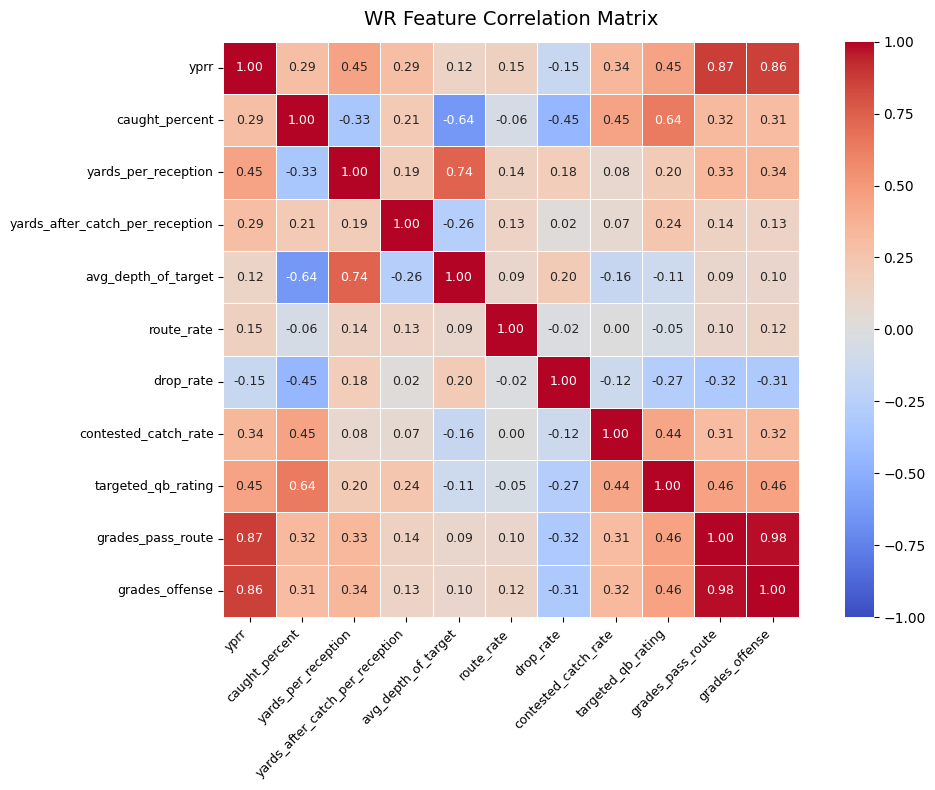

Highly correlated pairs (|r| > 0.85):
  yprr & grades_pass_route: 0.87
  yprr & grades_offense: 0.86
  grades_pass_route & grades_offense: 0.98


In [ ]:
#correlation heat map to ensure there is no multicollinearity
import matplotlib.pyplot as plt
import seaborn as sns

features = [
    'yprr',                        # yards per route run — best single WR metric
    'caught_percent',              # catch rate
    'yards_per_reception',         # efficiency per catch
    'yards_after_catch_per_reception', # YAC ability
    'avg_depth_of_target',         # scheme context / route depth
    'route_rate',                  # involvement / trust from QB
    'drop_rate',                   # ball security
    'contested_catch_rate',        # winning 50/50 balls
    'targeted_qb_rating',          # QB rating when targeting this WR
    'grades_pass_route',           # PFF route running grade
    'grades_offense',
]

corr = combined[features].corr().round(2)

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot_kws={'size': 9}
)
plt.title('WR Feature Correlation Matrix', fontsize=14, pad=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

# Print any highly correlated pairs
print('Highly correlated pairs (|r| > 0.85):')
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        val = corr.iloc[i, j]
        if abs(val) > 0.85:
            print(f'  {corr.columns[i]} & {corr.columns[j]}: {val}')
            found = True
if not found:
    print('  None found')

In [ ]:
print(len(df))
print(df.columns.tolist())
print(df['player'].head(5))

61
['from_team', 'to_team', 'player', 'pos', 'years', 'value', 'aav', 'total_gtd', 'gtd_at_sign', 'aav_clean', 'signing_year']
0      Stefon Diggs
1       Cooper Kupp
2     Davante Adams
3    Darius Slayton
4       Josh Palmer
Name: player, dtype: object


Dataset: 133 rows, 104 unique players
Split → Train: 92 | Val: 18 | Test: 23

Best alpha: 0.032551  (val R²: 0.259)

── Train Metrics ──────────────────────────────────────
  R²:                    0.4509
  RMSE:                  1.4239% cap
  MAE:                   1.1390% cap
  MAPE:                  95.22%
  Within 1% cap:         47.8% of players
  Within 2% cap:         87.0% of players

── Val Metrics ──────────────────────────────────────
  R²:                    0.3623
  RMSE:                  2.2720% cap
  MAE:                   1.7225% cap
  MAPE:                  83.88%
  Within 1% cap:         44.4% of players
  Within 2% cap:         66.7% of players

── Test Metrics ──────────────────────────────────────
  R²:                    0.2107
  RMSE:                  1.9780% cap
  MAE:                   1.4626% cap
  MAPE:                  65.67%
  Within 1% cap:         47.8% of players
  Within 2% cap:         78.3% of players

── Feature Coefficients ─────────────────────────

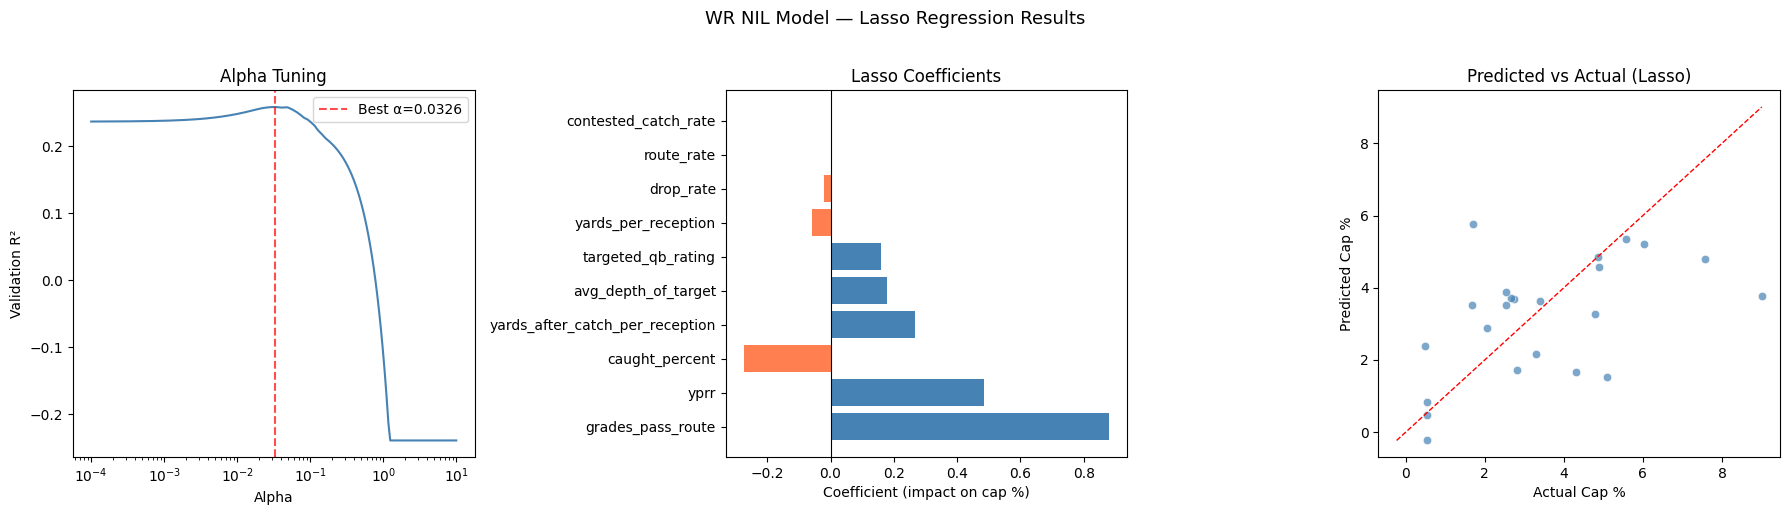

In [ ]:
#training model using lasso regressiom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

df = combined.copy()

FEATURES = [
    'yprr',                        # yards per route run — best single WR metric
    'caught_percent',              # catch rate
    'yards_per_reception',         # efficiency per catch
    'yards_after_catch_per_reception', # YAC ability
    'avg_depth_of_target',         # scheme context / route depth
    'route_rate',                  # involvement / trust from QB
    'drop_rate',                   # ball security
    'contested_catch_rate',        # winning 50/50 balls
    'targeted_qb_rating',          # QB rating when targeting this WR
    'grades_pass_route',           # PFF route running grade
]
TARGET = 'cap_percent'

df = df[FEATURES + [TARGET, 'player']].dropna()
print(f'Dataset: {len(df)} rows, {df["player"].nunique()} unique players')

X      = df[FEATURES].values
y      = df[TARGET].values
groups = df['player'].values

# ── 2. Grouped train / val / test split ───────────────────────────────────────

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
dev_idx, test_idx = next(gss_test.split(X, y, groups))

X_dev,  y_dev,  groups_dev = X[dev_idx],  y[dev_idx],  groups[dev_idx]
X_test, y_test              = X[test_idx], y[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=42)
train_idx, val_idx = next(gss_val.split(X_dev, y_dev, groups_dev))

X_train, y_train = X_dev[train_idx], y_dev[train_idx]
X_val,   y_val   = X_dev[val_idx],   y_dev[val_idx]

print(f'Split → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# ── 3. Scale ──────────────────────────────────────────────────────────────────

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── 4. Tune alpha on validation set ──────────────────────────────────────────

alphas     = np.logspace(-4, 1, 200)
val_scores = []

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train_s, y_train)
    val_scores.append(r2_score(y_val, model.predict(X_val_s)))

best_alpha = alphas[np.argmax(val_scores)]
best_val_r2 = max(val_scores)
print(f'\nBest alpha: {best_alpha:.6f}  (val R²: {best_val_r2:.3f})')

# ── 5. Retrain on train+val, evaluate on test ─────────────────────────────────

X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval   = np.concatenate([y_train, y_val])

model = Lasso(alpha=best_alpha, max_iter=10000)
model.fit(X_trainval_s, y_trainval)

# ── 6. Full metrics ───────────────────────────────────────────────────────────

def full_report(y_true, y_pred, split_name):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    within_1pct = np.mean(np.abs(y_true - y_pred) <= 1.0) * 100
    within_2pct = np.mean(np.abs(y_true - y_pred) <= 2.0) * 100
    print(f'\n── {split_name} Metrics ──────────────────────────────────────')
    print(f'  R²:                    {r2:.4f}')
    print(f'  RMSE:                  {rmse:.4f}% cap')
    print(f'  MAE:                   {mae:.4f}% cap')
    print(f'  MAPE:                  {mape:.2f}%')
    print(f'  Within 1% cap:         {within_1pct:.1f}% of players')
    print(f'  Within 2% cap:         {within_2pct:.1f}% of players')
    return r2, rmse, mae

train_preds = model.predict(X_train_s)
val_preds   = model.predict(X_val_s)
test_preds  = model.predict(X_test_s)

full_report(y_train, train_preds, 'Train')
full_report(y_val,   val_preds,   'Val')
full_report(y_test,  test_preds,  'Test')

# ── 7. Coefficients ───────────────────────────────────────────────────────────

coef_df = pd.DataFrame({
    'feature': FEATURES,
    'coefficient': model.coef_,
}).sort_values('coefficient', key=abs, ascending=False)

print('\n── Feature Coefficients ─────────────────────────────────────────')
print(f'  Intercept: {model.intercept_:.4f}')
print(coef_df.to_string(index=False))
zeroed = coef_df[coef_df['coefficient'] == 0]
if len(zeroed) > 0:
    print(f'\n  Lasso zeroed out: {zeroed["feature"].tolist()}')

# ── 8. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Alpha tuning
axes[0].plot(alphas, val_scores, color='steelblue')
axes[0].axvline(best_alpha, color='red', linestyle='--', alpha=0.7, label=f'Best α={best_alpha:.4f}')
axes[0].set_xscale('log')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('Validation R²')
axes[0].set_title('Alpha Tuning')
axes[0].legend()

# (b) Coefficients
colors = ['steelblue' if c >= 0 else 'coral' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Lasso Coefficients')
axes[1].set_xlabel('Coefficient (impact on cap %)')

# (c) Predicted vs actual
axes[2].scatter(y_test, test_preds, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_test.min(), test_preds.min())
max_val = max(y_test.max(), test_preds.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[2].set_xlabel('Actual Cap %')
axes[2].set_ylabel('Predicted Cap %')
axes[2].set_title('Predicted vs Actual (Lasso)')

plt.suptitle('WR NIL Model — Lasso Regression Results', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 9. Prediction function ────────────────────────────────────────────────────

def predict_nil_percent(player_stats: dict, total_nil_budget: float = None) -> dict:
    input_df     = pd.DataFrame([player_stats])[FEATURES]
    input_scaled = scaler.transform(input_df)
    cap_pct      = float(model.predict(input_scaled)[0])
    cap_pct      = max(0, cap_pct)

    result = {'predicted_cap_percent': round(cap_pct, 4)}
    if total_nil_budget:
        result['recommended_nil_dollars'] = round(cap_pct / 100 * total_nil_budget, 2)
    return result

Dataset: 133 rows, 104 unique players

Target distribution:
count    133.0000
mean       2.7859
std        2.2041
min        0.3555
25%        0.9397
50%        2.2573
75%        4.3836
max        9.8630
Name: cap_percent, dtype: float64

Split → Train: 92 | Val: 18 | Test: 23

Best params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': 3}
Best CV R²:  0.301

── Train Metrics ──────────────────────────────────────
  R² (log scale):        0.6039
  R² (original scale):   0.6045
  RMSE:                  1.2085% cap
  MAE:                   0.8894% cap
  MAPE:                  58.52%
  Within 1% cap:         66.3% of players
  Within 2% cap:         90.2% of players

── Val Metrics ──────────────────────────────────────
  R² (log scale):        0.6752
  R² (original scale):   0.5049
  RMSE:                  2.0019% cap
  MAE:                   1.4964% cap
  MAPE:                  53.09%
  Within 1% cap:         61.1% of players
  Wit

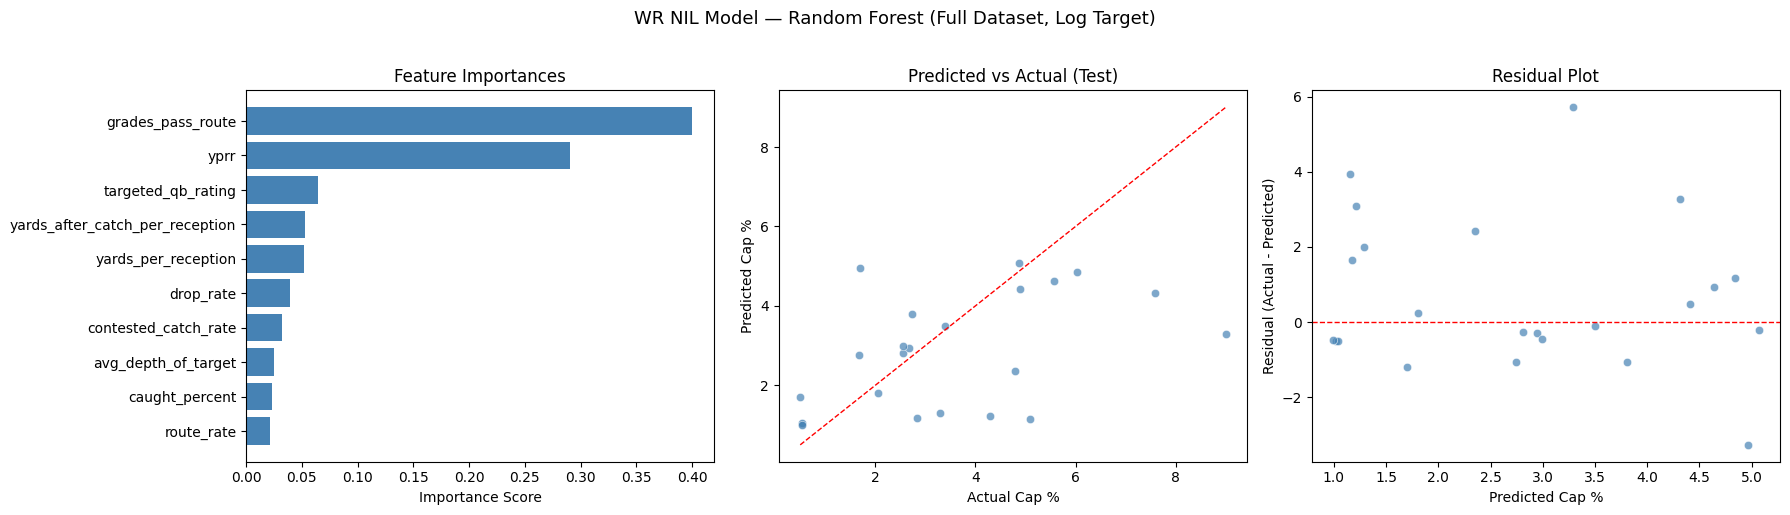

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ── 1. Load & prep ────────────────────────────────────────────────────────────

df = combined.copy()

FEATURES = [
    'yprr',                        # yards per route run — best single WR metric
    'caught_percent',              # catch rate
    'yards_per_reception',         # efficiency per catch
    'yards_after_catch_per_reception', # YAC ability
    'avg_depth_of_target',         # scheme context / route depth
    'route_rate',                  # involvement / trust from QB
    'drop_rate',                   # ball security
    'contested_catch_rate',        # winning 50/50 balls
    'targeted_qb_rating',          # QB rating when targeting this WR
    'grades_pass_route',           # PFF route running grade
]
TARGET     = 'cap_percent'
TARGET_LOG = 'cap_percent_log'

df = df[FEATURES + [TARGET, 'player']].dropna()
df[TARGET_LOG] = np.log1p(df[TARGET])

print(f'Dataset: {len(df)} rows, {df["player"].nunique()} unique players')
print(f'\nTarget distribution:')
print(df[TARGET].describe().round(4))

X      = df[FEATURES].values
y      = df[TARGET_LOG].values
y_orig = df[TARGET].values
groups = df['player'].values

# ── 2. Grouped train / val / test split ───────────────────────────────────────

gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
dev_idx, test_idx = next(gss_test.split(X, y, groups))

X_dev,  y_dev,  y_orig_dev,  groups_dev = X[dev_idx],  y[dev_idx],  y_orig[dev_idx],  groups[dev_idx]
X_test, y_test, y_orig_test             = X[test_idx], y[test_idx], y_orig[test_idx]

gss_val = GroupShuffleSplit(n_splits=1, test_size=0.15 / 0.85, random_state=42)
train_idx, val_idx = next(gss_val.split(X_dev, y_dev, groups_dev))

X_train, y_train, y_orig_train = X_dev[train_idx], y_dev[train_idx], y_orig_dev[train_idx]
X_val,   y_val,   y_orig_val   = X_dev[val_idx],   y_dev[val_idx],   y_orig_dev[val_idx]

print(f'\nSplit → Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')

# ── 3. Scale ──────────────────────────────────────────────────────────────────

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# ── 4. Hyperparameter search ──────────────────────────────────────────────────

param_grid = {
    'n_estimators':      [100, 200, 300, 500],
    'max_depth':         [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2', 0.5],
}

rf = RandomForestRegressor(
    max_depth=5,
    min_samples_leaf=5,
    max_features='sqrt',
    n_estimators=300,
    random_state=42
)
search = RandomizedSearchCV(
    rf, param_grid,
    n_iter=50,
    scoring='r2',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=0
)
search.fit(X_train_s, y_train)

print(f'\nBest params: {search.best_params_}')
print(f'Best CV R²:  {search.best_score_:.3f}')

# ── 5. Retrain on train+val, evaluate on test ─────────────────────────────────

X_trainval_s = np.vstack([X_train_s, X_val_s])
y_trainval   = np.concatenate([y_train, y_val])

rf_final = RandomForestRegressor(**search.best_params_, random_state=42)
rf_final.fit(X_trainval_s, y_trainval)

# ── 6. Full metrics ───────────────────────────────────────────────────────────

def full_report(y_true_log, y_true_orig, y_pred_log, split_name):
    y_pred_orig  = np.expm1(y_pred_log)
    r2_log       = r2_score(y_true_log,  y_pred_log)
    r2_orig      = r2_score(y_true_orig, y_pred_orig)
    rmse         = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    mae          = np.mean(np.abs(y_true_orig - y_pred_orig))
    nonzero_mask = y_true_orig > 0.1
    mape         = np.mean(np.abs((y_true_orig[nonzero_mask] - y_pred_orig[nonzero_mask]) / y_true_orig[nonzero_mask])) * 100
    within_1pct  = np.mean(np.abs(y_true_orig - y_pred_orig) <= 1.0) * 100
    within_2pct  = np.mean(np.abs(y_true_orig - y_pred_orig) <= 2.0) * 100

    print(f'\n── {split_name} Metrics ──────────────────────────────────────')
    print(f'  R² (log scale):        {r2_log:.4f}')
    print(f'  R² (original scale):   {r2_orig:.4f}')
    print(f'  RMSE:                  {rmse:.4f}% cap')
    print(f'  MAE:                   {mae:.4f}% cap')
    print(f'  MAPE:                  {mape:.2f}%')
    print(f'  Within 1% cap:         {within_1pct:.1f}% of players')
    print(f'  Within 2% cap:         {within_2pct:.1f}% of players')
    return np.expm1(y_pred_log)

train_preds = full_report(y_train, y_orig_train, rf_final.predict(X_train_s), 'Train')
val_preds   = full_report(y_val,   y_orig_val,   rf_final.predict(X_val_s),   'Val')
test_preds  = full_report(y_test,  y_orig_test,  rf_final.predict(X_test_s),  'Test')

# ── 7. Feature importances ────────────────────────────────────────────────────

importance_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': rf_final.feature_importances_,
}).sort_values('importance', ascending=False)

print('\n── Feature Importances ──────────────────────────────────────────')
print(importance_df.to_string(index=False))

# ── 8. Plots ──────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (a) Feature importances
axes[0].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[0].invert_yaxis()
axes[0].set_title('Feature Importances')
axes[0].set_xlabel('Importance Score')

# (b) Predicted vs actual
axes[1].scatter(y_orig_test, test_preds, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
min_val = min(y_orig_test.min(), test_preds.min())
max_val = max(y_orig_test.max(), test_preds.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1)
axes[1].set_xlabel('Actual Cap %')
axes[1].set_ylabel('Predicted Cap %')
axes[1].set_title('Predicted vs Actual (Test)')

# (c) Residuals
residuals = y_orig_test - test_preds
axes[2].scatter(test_preds, residuals, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Predicted Cap %')
axes[2].set_ylabel('Residual (Actual - Predicted)')
axes[2].set_title('Residual Plot')

plt.suptitle('WR NIL Model — Random Forest (Full Dataset, Log Target)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── 9. Prediction function ────────────────────────────────────────────────────

def predict_nil_percent(player_stats: dict, total_nil_budget: float = None) -> dict:
    input_df     = pd.DataFrame([player_stats])[FEATURES]
    input_scaled = scaler.transform(input_df)
    cap_pct_log  = float(rf_final.predict(input_scaled)[0])
    cap_pct      = float(np.expm1(cap_pct_log))
    cap_pct      = max(0, cap_pct)

    result = {'predicted_cap_percent': round(cap_pct, 4)}
    if total_nil_budget:
        result['recommended_nil_dollars'] = round(cap_pct / 100 * total_nil_budget, 2)
    return result


In [ ]:
# See exactly who's in your test set and how wrong predictions are
test_df = df.iloc[test_idx][['player', 'cap_percent']].copy()
test_df['predicted'] = test_preds
test_df['error'] = abs(test_df['cap_percent'] - test_df['predicted'])
test_df = test_df.sort_values('error', ascending=False)
print(test_df.to_string(index=False))

           player  cap_percent  predicted    error
    Calvin Ridley       9.0055   3.285549 5.719951
   Darnell Mooney       5.0901   1.151841 3.938259
     Stefon Diggs       7.5812   4.312755 3.268445
    Antonio Brown       1.6986   4.964582 3.265982
   Darius Slayton       4.2980   1.212991 3.085009
       John Brown       4.7821   2.354358 2.427742
       A.J. Green       3.2877   1.289237 1.998463
       John Brown       2.8217   1.168558 1.653142
    Tavarres King       0.4966   1.697880 1.201280
   Nelson Agholor       6.0274   4.845313 1.182087
       A.J. Green       1.6811   2.748410 1.067310
  Kendrick Bourne       2.7397   3.806491 1.066791
    Antonio Brown       5.5792   4.637213 0.941987
 Geronimo Allison       0.5285   1.036501 0.508001
       Ryan Grant       0.5313   1.021430 0.490130
    Jakobi Meyers       4.8932   4.411712 0.481488
   Nelson Agholor       0.5285   0.992185 0.463685
  Kendrick Bourne       2.5450   2.996343 0.451343
   Darius Slayton       2.6690 

In [ ]:
from sklearn.model_selection import cross_val_score, GroupKFold

gkf = GroupKFold(n_splits=5)
scores = cross_val_score(rf_final, X, y, groups=groups, cv=gkf, scoring='r2')
print(f'CV R² scores: {scores.round(3)}')
print(f'Mean R²: {scores.mean():.3f} ± {scores.std():.3f}')

CV R² scores: [0.11  0.324 0.371 0.252 0.346]
Mean R²: 0.280 ± 0.094


In [ ]:
import joblib
import os

# Create the directory if it doesn't exist
os.makedirs('backend/models', exist_ok=True)

joblib.dump(rf_final, 'backend/models/wr_model.pkl')
joblib.dump(scaler, 'backend/models/wr_scaler.pkl')

print('WR model saved successfully')

WR model saved successfully


In [ ]:
import os
print(os.listdir('backend/models'))
# should print: ['qb_model.pkl', 'qb_scaler.pkl', 'wr_model.pkl', 'wr_scaler.pkl']

['wr_model.pkl', 'wr_scaler.pkl', 'qb_scaler.pkl', 'qb_model.pkl']


In [ ]:
import numpy as np
from sklearn.metrics import r2_score

y_mean = np.mean(y_orig)
baseline_preds = np.full_like(y_orig, y_mean)

baseline_r2   = r2_score(y_orig, baseline_preds)
baseline_mae  = np.mean(np.abs(y_orig - baseline_preds))
baseline_rmse = np.sqrt(np.mean((y_orig - baseline_preds) ** 2))

print(f'── Baseline (predict mean for everyone) ──────────────────')
print(f'  Mean cap%:    {y_mean:.4f}%')
print(f'  R²:           {baseline_r2:.4f}')
print(f'  MAE:          {baseline_mae:.4f}% cap')
print(f'  RMSE:         {baseline_rmse:.4f}% cap')

── Baseline (predict mean for everyone) ──────────────────
  Mean cap%:    2.7859%
  R²:           0.0000
  MAE:          1.8174% cap
  RMSE:         2.1958% cap
